In [30]:
# importing necessary libraries
import cv2
from deepface import DeepFace
import matplotlib.pyplot as plt
import numpy as np
import os

In [33]:
# loading first 10 images from each category in the dataset
base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))  # go up one folder
dataset_path = os.path.join(base_dir, "datasets", "facial_expression_dataset", "train","train")
print("Dataset path:", dataset_path)
categories = [ 'angry','happy', 'sad', 'neutral', 'disgust', 'fear', 'surprise']  
images = []
labels = []
for category in categories:
    category_path = os.path.join(dataset_path, category)
    for img_name in os.listdir(category_path)[:10]:  # load first 10 images
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            images.append(img)
            labels.append(category)

Dataset path: d:\Github repos\Sign-Language-project\datasets\facial_expression_dataset\train\train


Error analyzing image 0: module 'deepface.modules.modeling' has no attribute 'build_model'
Error analyzing image 1: module 'deepface.modules.modeling' has no attribute 'build_model'
Error analyzing image 2: module 'deepface.modules.modeling' has no attribute 'build_model'
Error analyzing image 3: module 'deepface.modules.modeling' has no attribute 'build_model'
Error analyzing image 4: module 'deepface.modules.modeling' has no attribute 'build_model'
Error analyzing image 5: module 'deepface.modules.modeling' has no attribute 'build_model'
Error analyzing image 6: module 'deepface.modules.modeling' has no attribute 'build_model'
Error analyzing image 7: module 'deepface.modules.modeling' has no attribute 'build_model'
Error analyzing image 8: module 'deepface.modules.modeling' has no attribute 'build_model'
Error analyzing image 9: module 'deepface.modules.modeling' has no attribute 'build_model'
Error analyzing image 10: module 'deepface.modules.modeling' has no attribute 'build_model

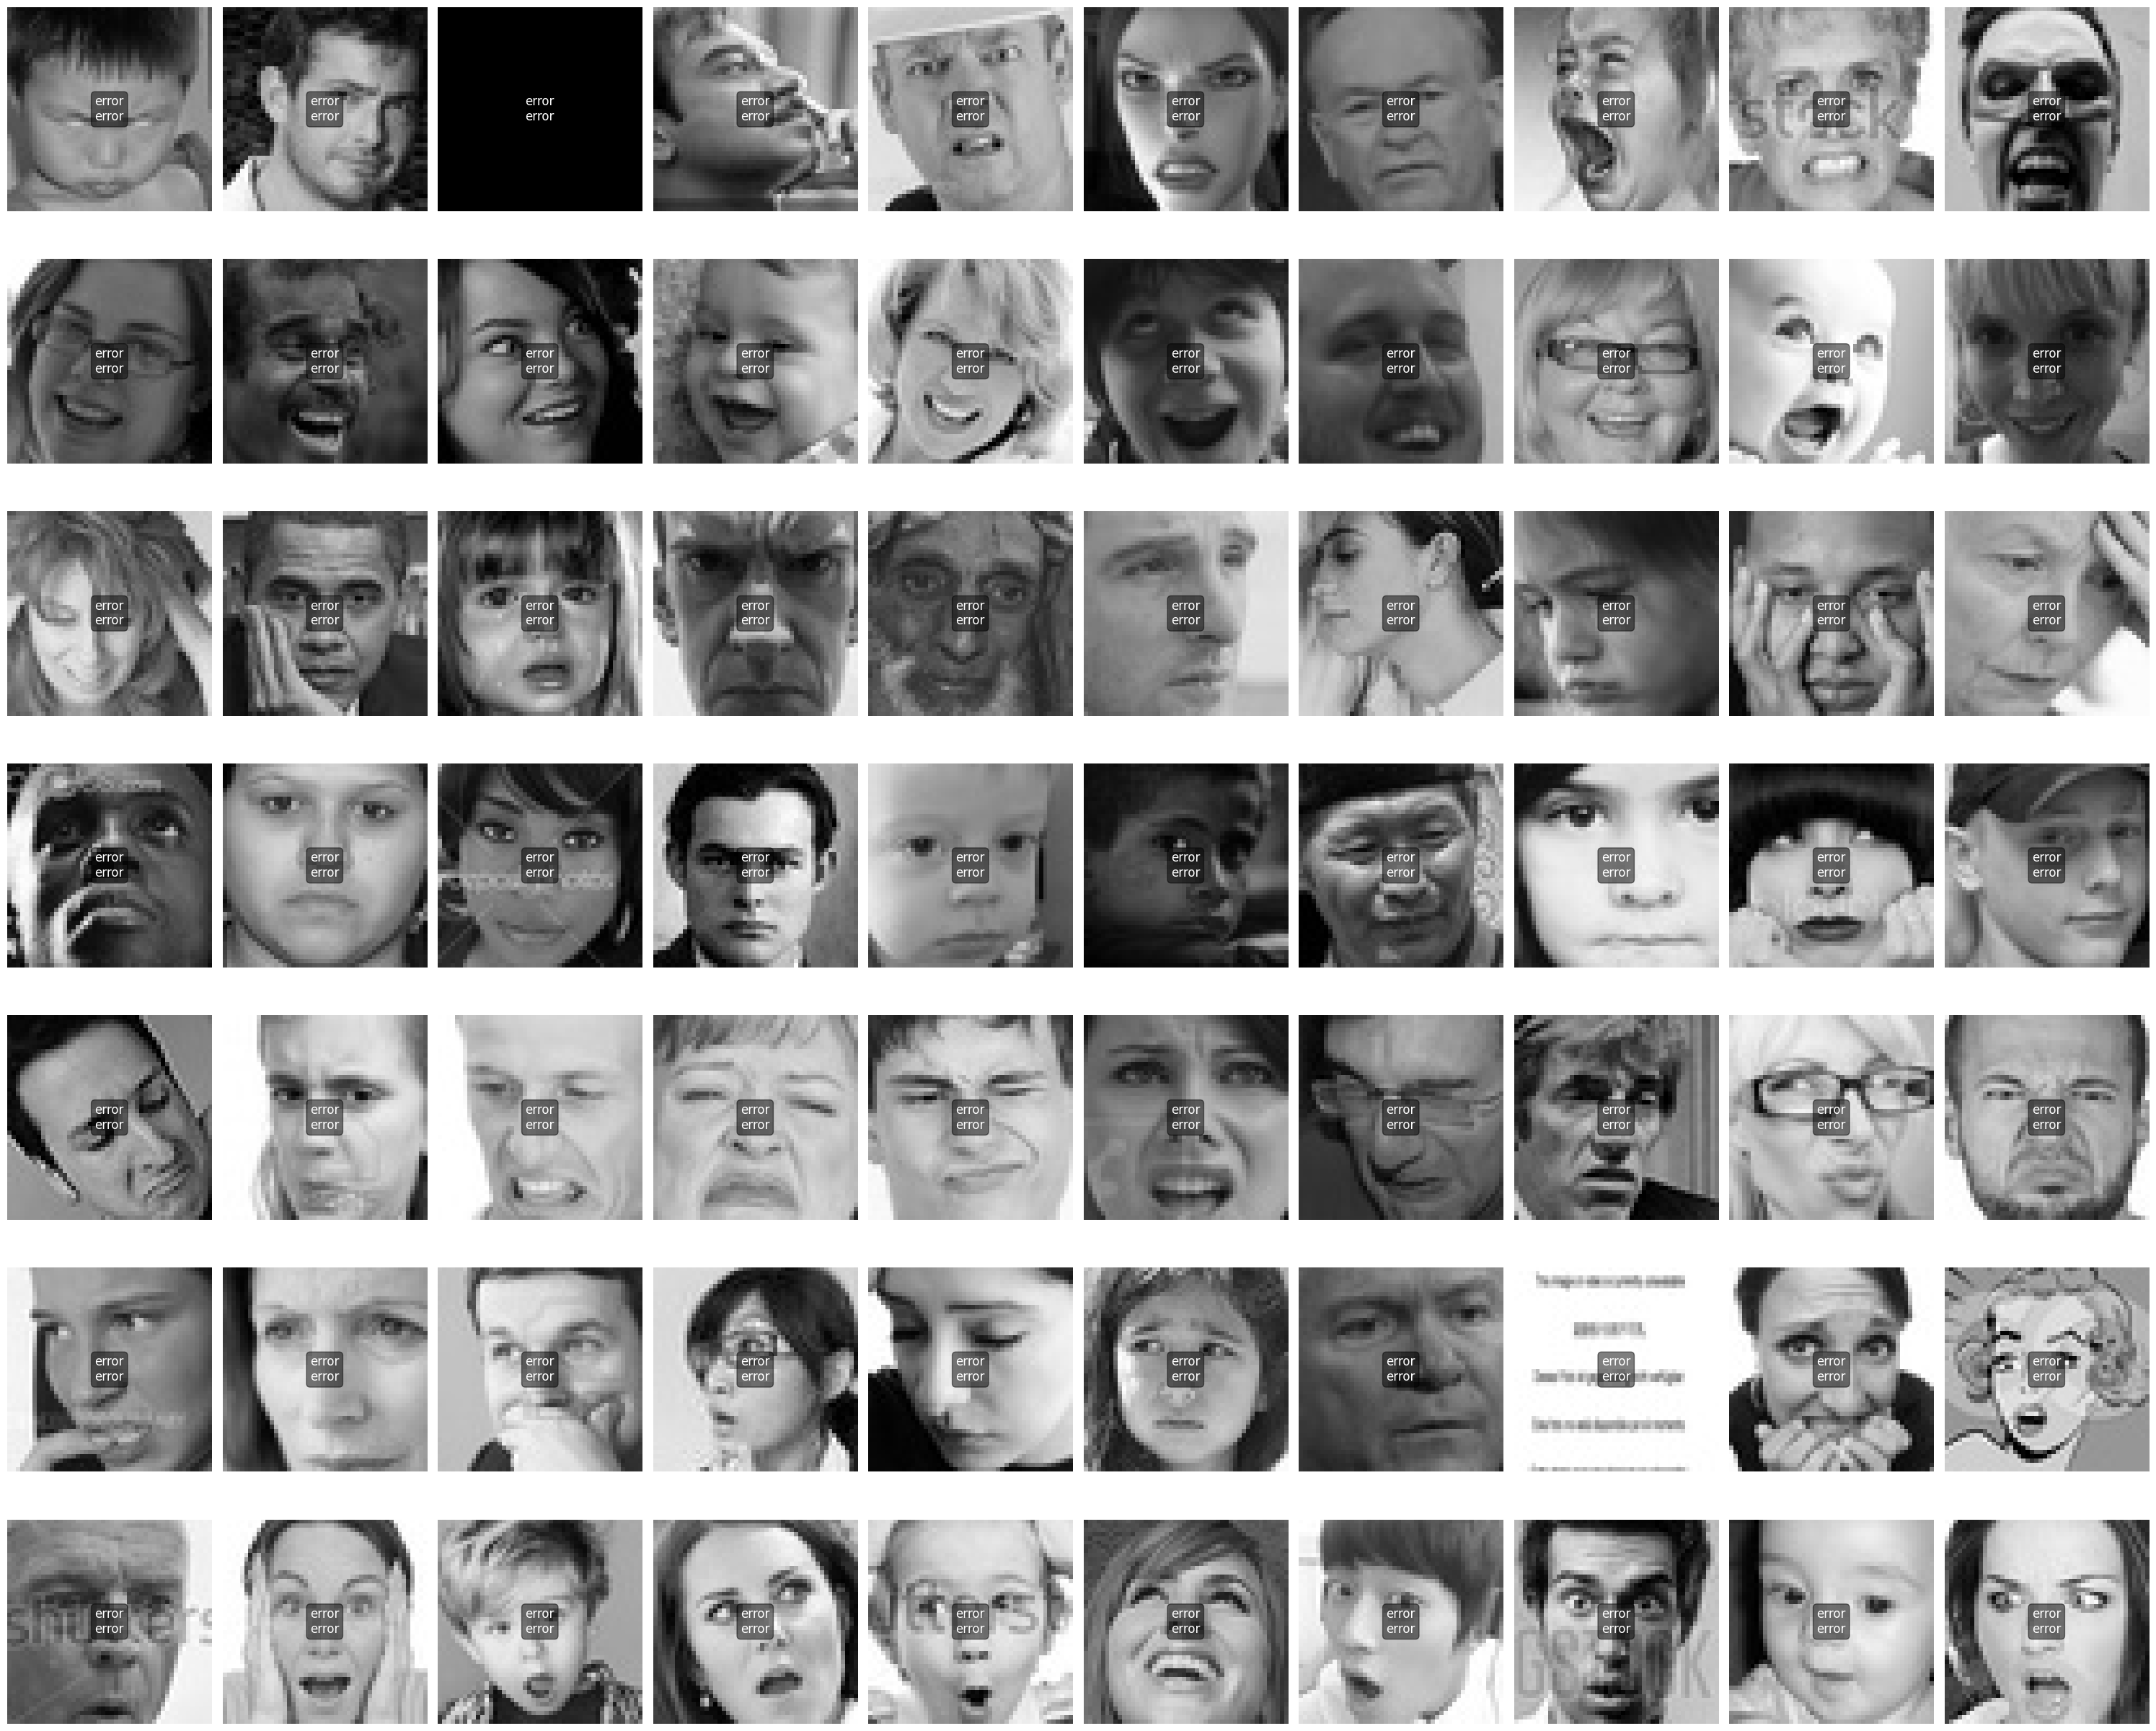

In [ ]:
import matplotlib.pyplot as plt
from deepface import DeepFace
import cv2

plt.figure(figsize=(30, 25))

for i, img in enumerate(images):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    try:
        # DeepFace analyze
        analysis = DeepFace.analyze(rgb, actions=['emotion', 'gender'], enforce_detection=False)
        
        # Safe extraction
        if isinstance(analysis, list):  # old versions return list
            analysis = analysis[0]
        
        pred_emotion = analysis.get('dominant_emotion', 'unknown')
        gender = analysis.get('gender', 'unknown')
        
    except Exception as e:
        print(f"Error analyzing image {i}: {e}")
        pred_emotion = 'error'
        gender = 'error'

    # Plot image
    plt.subplot(7, 10, i + 1)
    plt.imshow(rgb)
    plt.text(
        0.5, 0.5, f"{pred_emotion}\n{gender}",
        ha='center', va='center',
        transform=plt.gca().transAxes,
        fontsize=12,
        color='white',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.6)
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

In [39]:
# Test with one image to see the error
import cv2
from deepface import DeepFace
import matplotlib.pyplot as plt
import numpy as np
import os

# Load one image
base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
dataset_path = os.path.join(base_dir, "datasets", "facial_expression_dataset", "train","train")
img_path = os.path.join(dataset_path, "angry", os.listdir(os.path.join(dataset_path, "angry"))[0])
img = cv2.imread(img_path)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Testing DeepFace on one image...")
try:
    analysis = DeepFace.analyze(rgb, actions=['emotion', 'gender'], enforce_detection=False)
    print("Analysis result:", analysis)
    if analysis:
        pred_emotion = analysis[0].get('dominant_emotion', 'unknown')
        gender = analysis[0].get('gender', 'unknown')
        print(f"Emotion: {pred_emotion}, Gender: {gender}")
    else:
        print("No face detected")
except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

Testing DeepFace on one image...
Error: module 'deepface.modules.modeling' has no attribute 'build_model'


Traceback (most recent call last):
  File "C:\Users\hp\AppData\Local\Temp\ipykernel_46104\2981550390.py", line 17, in <module>
    analysis = DeepFace.analyze(rgb, actions=['emotion', 'gender'], enforce_detection=False)
  File "c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\deepface\DeepFace.py", line 269, in analyze
    return demography.analyze(
  File "c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\deepface\modules\demography.py", line 153, in analyze
    detection.extract_faces(
  File "c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\deepface\modules\detection.py", line 150, in extract_faces
    face_objs = detect_faces(
  File "c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\deepface\modules\detection.py", line 295, in detect_faces
    face_detector: Detector = modeling.build_model(
AttributeError: module 'deepface.modules.modeling' has no attribute 'build_model'
